In [1]:
%run ChartsCommon.ipynb

In [2]:
def plotDynAndStaticVsBase(our_df, deviationsText, titleText, relations):

    #filtered_df = our_df[our_df['relation'].isin(['stat_vs_base', 'dyn_vs_base'])].copy()
    filtered_df = our_df[our_df['relation'].isin(relations)].copy()# ['internal']
    filtered_df['alg_rel'] = filtered_df['algorithm'] + ' - ' + filtered_df['relation']
    #print("filtered_df\n", filtered_df)

    fig, ax = plt.subplots(figsize=(24, 12))
    ax = sns.barplot(
        data=filtered_df,
        x='size',
        y='ratio',
        hue='alg_rel',
        estimator=gmean,
        palette=palette,
        ci=None
    )
    if "internal" in relations:
        baseline_line = plt.axhline(y=1, color='red', linestyle='--', linewidth=1.5, label='Equal')
    #ax.set_yscale("log")
    plt.xticks(rotation=45)
    #plt.ylim(80000, 200000)

    #plt.tight_layout()
    #plt.ylim(25000, 210000)
    plt.yticks(fontsize=32)
    plt.xticks(fontsize=32)
    plt.xlabel('Workflow size', fontsize=32)
    plt.ylabel('Improvement over the baseline, times', fontsize=32)
    plt.legend(fontsize=32, title_fontsize=32)  


    # Get current tick labels and modify them
    xticks = ax.get_xticks()
    xticklabels = [tick.get_text() for tick in ax.get_xticklabels()]

    # Replace label "100" with "<100"
    new_labels = ["<100" if lbl == "100" else lbl for lbl in xticklabels]

    # Apply the modified labels
    ax.set_xticklabels(new_labels, fontsize=32, rotation=45, ha='right')

    handles, labels = ax.get_legend_handles_labels()

    # Apply the mapping
    pretty_labels = [label_map.get(lbl, lbl) for lbl in labels]

    
    # Set updated legend
    ax.legend(handles, pretty_labels, title="Algorithm Variant", fontsize=24, title_fontsize=26)
   # plt.title(f'{titleText} {deviationsText}', fontsize=28) #Makespan improvement over the baseline,


    #inset_ax = inset_axes(ax, width="40%", height="45%", loc='upper left',
    #                      bbox_to_anchor=(0.1, 0.55, 0.4, 0.4), bbox_transform=fig.transFigure)
    inset_ax = inset_axes(ax,
                          width="35%", height="45%", loc='lower left',
                          bbox_to_anchor=(0.135, 0.12, 0.4, 0.4),  # <-- lower position
                          #(0.135, 0.12, 0.4, 0.4)
                          bbox_transform=fig.transFigure)

    # Filter for small sizes (100 and 200)
    small_df = filtered_df[filtered_df['size'].isin([100, 200])]

    sns.barplot(data=small_df, x='size', y='ratio', hue='alg_rel', ax=inset_ax, estimator=gmean,  palette=palette,ci=None)
    inset_ax.set_yscale("log")  # Show small differences better
    inset_ax.set_title("Zoom on small \n sizes (log scale)", fontsize=24, color='red')
    inset_ax.tick_params(axis='both', labelsize=20)
    inset_ax.set_xlabel("")
    inset_ax.set_ylabel("")
    inset_ax.set_xticklabels([])
    inset_ax.tick_params(axis='y', colors='red')

    for spine in inset_ax.spines.values():
        spine.set_edgecolor('red')
        spine.set_linewidth(2)  # Adjust thickness as needed

    # Optionally draw a rectangle to highlight the zoomed region
    # from mpl_toolkits.axes_grid1.inset_locator import mark_inset
    # mark_inset(ax, inset_ax, loc1=2, loc2=4, fc="none", ec="0.5")

    # Clean up legend (show only one)
    #ax.legend(title="Algorithm Variant", fontsize=16, title_fontsize=16)
    inset_ax.get_legend().remove()

    #plt.tight_layout()

    plt.savefig(f'improv_ov_baseline_newest_{deviationsText}.png', facecolor='white',  bbox_inches='tight')
    plt.show()

    grouped = filtered_df.groupby(['size', 'alg_rel'])['ratio'].agg(safe_gmean).reset_index()
    # Print the values used for bar heights
    print(grouped)

    gr = grouped.groupby(['alg_rel'])['ratio'].agg(safe_gmean)
    print(gr)

In [3]:
%run ChartsCommon.ipynb

./results/merged/*.txt
     size  algorithm     ratio
0     100   MeDiH-BL  0.784381
1     100  MeDiH-BLC  0.819582
2     100   MeDiH-MM  0.994319
3     200   MeDiH-BL  1.395850
4     200  MeDiH-BLC  1.403393
5     200   MeDiH-MM  0.955100
6    1000   MeDiH-BL  0.897842
7    1000  MeDiH-BLC  0.927628
8    1000   MeDiH-MM  0.820342
9    2000   MeDiH-BL  0.721529
10   2000  MeDiH-BLC  0.769715
11   2000   MeDiH-MM  0.816123
12   4000   MeDiH-BL  0.651458
13   4000  MeDiH-BLC  0.675408
14   4000   MeDiH-MM  0.871323
15   8000   MeDiH-BL  0.557287
16   8000  MeDiH-BLC  0.565674
17   8000   MeDiH-MM  0.925050
18  10000   MeDiH-BL  0.558652
19  10000  MeDiH-BLC  0.546780
20  10000   MeDiH-MM  0.929024
21  15000   MeDiH-BL  0.508102
22  15000  MeDiH-BLC  0.511141
23  15000   MeDiH-MM  1.000208
24  20000   MeDiH-BL  0.483772
25  20000  MeDiH-BLC  0.496828
26  20000   MeDiH-MM  1.031585
27  25000   MeDiH-BL  0.471282
28  25000  MeDiH-BLC  0.486042
29  25000   MeDiH-MM  1.050795
30  30000   MeDi

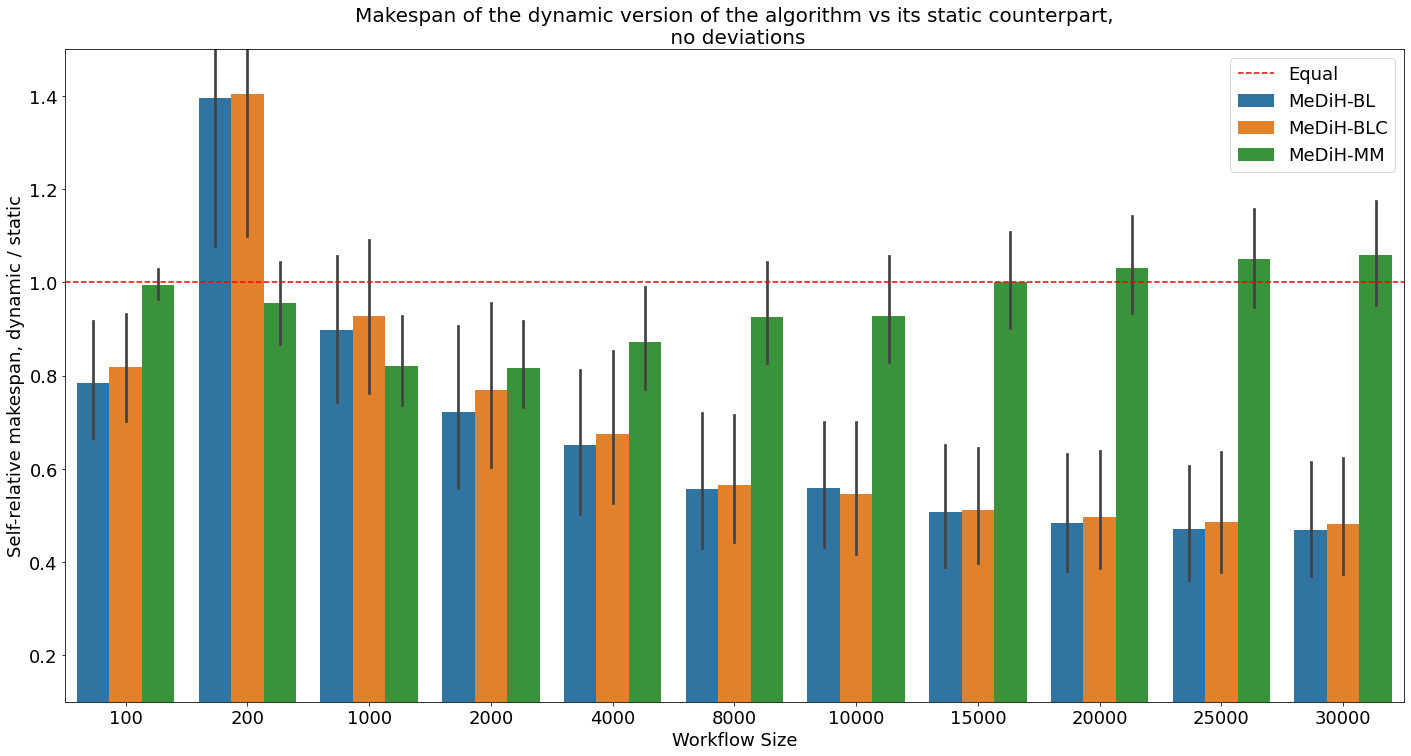

In [4]:

#path = "./param-study-pcsp/merged/*.txt"
#print(path)
#from scipy.stats import gmean

#patterndevs = r'^(BASE|A\d+)-ndev~(pspw\+\d)'

path = "./results/merged/*.txt"
print(path)

#patterndevs = r'^modified_(BASE|A\d+)_(\d\ddev)'
patterndevs = r'^(BASE|A\d+)-(\d\ddev|ndev)'

dfsrw=read_dfs(path,patterndevs, 2)
#print(dfsrw)

labels = ['A1', 'A2', 'A3', 'BASE']
dfsVar3 = [dfsrw[('A1','10dev')], dfsrw[('A2','10dev')], dfsrw[('A3','10dev')], dfsrw[('BASE','10dev')]]
merged_df_var3 = merge_correct_columns(dfsVar3, labels)
#print(merged_df_var1)
plot_df = buld_plot_df(merged_df_var3)
#print(plot_df.head())

plt.figure(figsize=(24, 12))

internal_df = plot_df[plot_df['relation'] == 'internal']

sns.barplot(data = internal_df, x = 'size', y ='ratio', hue = 'algorithm', estimator=gmean)  #, est=gmean
baseline_line = plt.axhline(y=1, color='red', linestyle='--', linewidth=1.5, label='Equal')


def safe_gmean(x):
    x = np.array(x)
    x = x[x > 0]  # only positive values
    return gmean(x) if len(x) > 0 else np.nan

grouped = internal_df.groupby(['size', 'algorithm'])['ratio'].agg(safe_gmean).reset_index()
# Print the values used for bar heights
print(grouped)

for name, group in internal_df.groupby(['size', 'algorithm']):
    if (group['ratio'] <= 0).any():
        print(f"Group {name} contains non-positive values:", group['ratio'].tolist())


plt.ylim(0.1, 1.5)

plt.yticks(fontsize=18)
plt.xticks(fontsize=18)
plt.xlabel('Workflow Size', fontsize=18)
plt.ylabel('Self-relative makespan, dynamic / static', fontsize=18)
plt.legend(fontsize=18)  
plt.title('Makespan of the dynamic version of the algorithm vs its static counterpart,\n no deviations', fontsize=20)
plt.savefig("static-vs-dynamic-no-devs.png", dpi=300)# bbox_inches='tight'
plt.show()

In [28]:
path = "./param-study-pcsp/merged/*.txt"
print(path)

patterndevs = r'^(BASE|A\d+)-ndev~(pspw\+\d)'

dfs=read_dfs(path,patterndevs, 2)
#print(dfs)


#dfsVar1 = [dfsrw[('A1','10dev')], dfsrw[('A1','30dev')], dfsrw[('A1','50dev')]]
labels = ['A1', 'A2', 'A3', 'BASE']
dfsVar1 = [dfs[('A1','pspw+2')], dfs[('A2','pspw+2')], dfs[('A3','pspw+2')], dfs[('BASE','pspw+2')]]
merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)
plot_df = buld_plot_df(merged_df_var1)
plotDynAndStaticVsBase(plot_df,"", "", # "no deviations", "Makespan improvement over baseline,"
                       ['stat_vs_base', 'dyn_vs_base'])#
                      # ['internal'])
allInternals = plot_df[plot_df['relation']=='internal']

./param-study-pcsp/merged/*.txt


KeyError: ('A1', 'pspw+2')

In [29]:
# Define the size categories
def size_category(size):
    if size <= 200:
        return 'small'
    elif 1000 <= size <= 8000:
        return 'middle'
    elif 10000 <= size <= 18000:
        return 'large'
    elif 20000 <= size <= 30000:
        return 'largest'
    else:
        return 'other'

allInternals = allInternals.copy()
allInternals = allInternals.dropna(subset=['ratio'])
#print(allInternals.to_string())
# Add a new column for size group
allInternals['size_group'] = allInternals['size'].apply(size_category)

# Filter only valid categories
filtered = allInternals[allInternals['size_group'] != 'other']

# Group by algorithm and size_group, then compute geometric mean
result = filtered.groupby(['algorithm', 'size_group'])['ratio'].agg(gmean).reset_index()

# Optionally, sort the result
size_order = ['small', 'middle', 'large', 'largest']
result['size_group'] = pd.Categorical(result['size_group'], categories=size_order, ordered=True)
result = result.sort_values(['algorithm', 'size_group'])

print(result)

by_algo = allInternals.groupby('algorithm')['ratio'].agg(gmean).reset_index()
print(by_algo)

NameError: name 'allInternals' is not defined

./results/merged/*.txt
No match found. A1-ndev.txt
No match found. A2-ndev.txt
No match found. A3-ndev.txt
No match found. BASE-ndev.txt
[                 wf_name     inp_size       ms_1_A1       ms_2_A1
0      atacseq_30000.dot  14091675276  1.412842e+09  1.584105e+09
1      chipseq_15000.dot  41366257414  3.267200e+09  7.724654e+09
2    methylseq_15000.dot   6761426956  1.227518e+08  4.992614e+08
3      atacseq_15000.dot   3908761308  2.055380e+08  1.648464e+08
4                  eager  19075314980  2.947654e+06  5.593867e+06
..                   ...          ...           ...           ...
252   methylseq_1000.dot   8885797810  1.063023e+07  1.356337e+07
253                eager  19132169434  3.233875e+06  5.852132e+06
254  methylseq_10000.dot  17027257018  3.127280e+08  1.515588e+09
255        eager_200.dot   8330435694  3.990719e+06  3.173356e+06
256    chipseq_10000.dot   4807293396  1.697077e+08  1.731230e+08

[257 rows x 4 columns],                  wf_name     inp_size       m

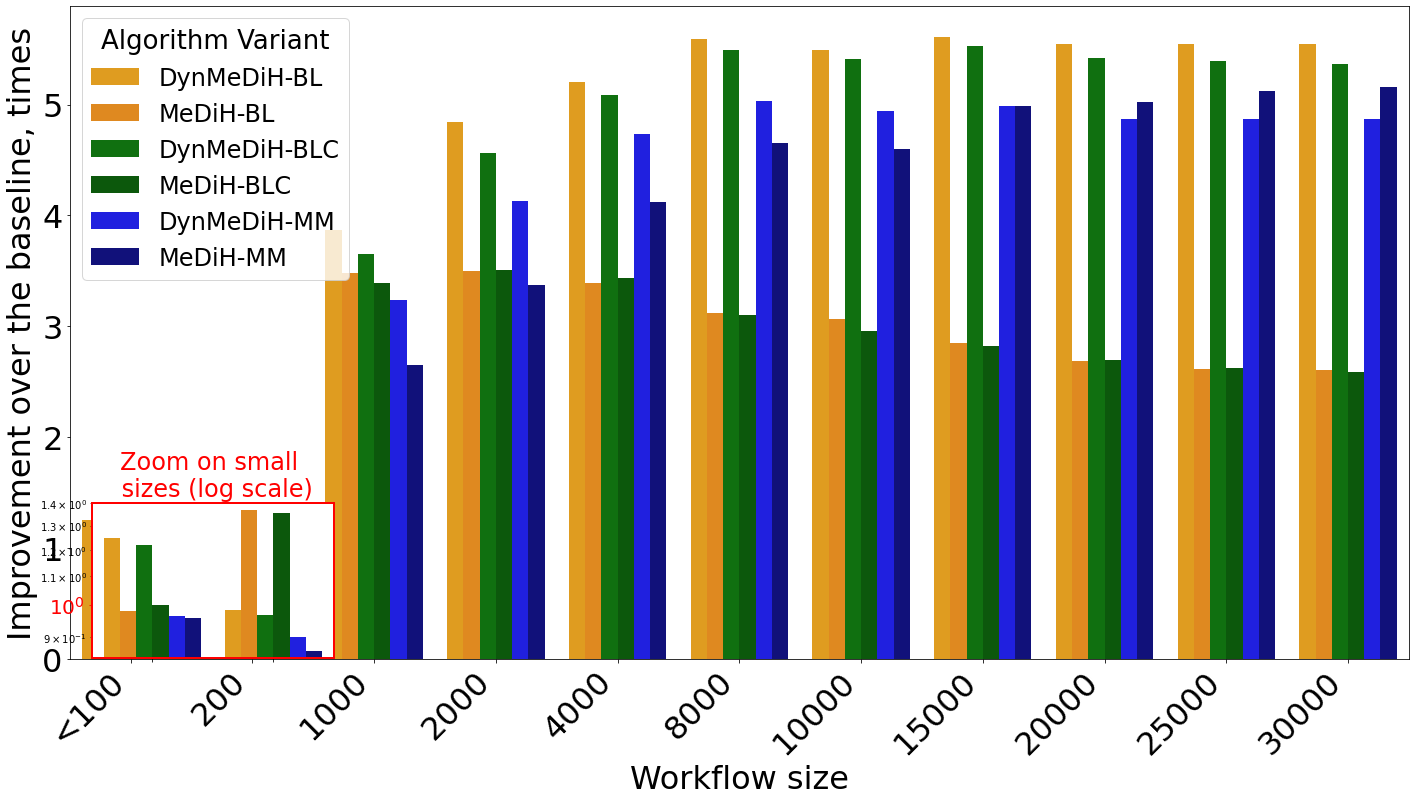

     size                   alg_rel     ratio
0     100    MeDiH-BL - dyn_vs_base  1.248149
1     100   MeDiH-BL - stat_vs_base  0.979024
2     100   MeDiH-BLC - dyn_vs_base  1.221335
3     100  MeDiH-BLC - stat_vs_base  1.000984
4     100    MeDiH-MM - dyn_vs_base  0.964637
..    ...                       ...       ...
61  30000   MeDiH-BL - stat_vs_base  2.603253
62  30000   MeDiH-BLC - dyn_vs_base  5.366035
63  30000  MeDiH-BLC - stat_vs_base  2.588595
64  30000    MeDiH-MM - dyn_vs_base  4.871135
65  30000   MeDiH-MM - stat_vs_base  5.157736

[66 rows x 3 columns]
alg_rel
MeDiH-BL - dyn_vs_base      3.936712
MeDiH-BL - stat_vs_base     2.532728
MeDiH-BLC - dyn_vs_base     3.827144
MeDiH-BLC - stat_vs_base    2.522887
MeDiH-MM - dyn_vs_base      3.435012
MeDiH-MM - stat_vs_base     3.251451
Name: ratio, dtype: float64


In [30]:
#############'THIS IS CORRECT ''''''''''''''''''''''''
#path = "./real-exps-correctparams/merged_final/*.txt"
path = "./results/merged/*.txt"
print(path)

#patterndevs = r'^modified_(BASE|A\d+)_(\d\ddev)'
patterndevs = r'^(BASE|A\d+)-(\d\ddev)'

dfs=read_dfs(path,patterndevs, 2)
#print(dfs)


#dfsVar1 = [dfsrw[('A1','10dev')], dfsrw[('A1','30dev')], dfsrw[('A1','50dev')]]
labels = ['A1', 'A2', 'A3', 'BASE']
dfsVar1 = [dfs[('A1','10dev')], dfs[('A2','10dev')], dfs[('A3','10dev')], dfs[('BASE','10dev')]]
#print(dfsVar1)
merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)
plot_df = buld_plot_df(merged_df_var1)
plotDynAndStaticVsBase(plot_df, "", "", ['stat_vs_base', 'dyn_vs_base'])# "deviations 10%", "Makespan improvement over baseline, ",
allInternals = plot_df[plot_df['relation']=='internal']

In [31]:
# Define the size categories
def size_category(size):
    if size <= 200:
        return 'small'
    elif 1000 <= size <= 8000:
        return 'middle'
    elif 10000 <= size <= 18000:
        return 'large'
    elif 20000 <= size <= 30000:
        return 'largest'
    else:
        return 'other'

allInternals = allInternals.copy()
#print(allInternals.to_string())
# Add a new column for size group
allInternals['size_group'] = allInternals['size'].apply(size_category)

# Filter only valid categories
filtered = allInternals[allInternals['size_group'] != 'other']

# Group by algorithm and size_group, then compute geometric mean
result = filtered.groupby(['algorithm', 'size_group'])['ratio'].agg(gmean).reset_index()

# Optionally, sort the result
size_order = ['small', 'middle', 'large', 'largest']
result['size_group'] = pd.Categorical(result['size_group'], categories=size_order, ordered=True)
result = result.sort_values(['algorithm', 'size_group'])

print(result)

by_algo = allInternals.groupby('algorithm')['ratio'].agg(gmean).reset_index()
print(by_algo)

    algorithm size_group     ratio
3    MeDiH-BL      small  1.105198
2    MeDiH-BL     middle  1.013005
0    MeDiH-BL      large  0.908603
1    MeDiH-BL    largest  0.900253
7   MeDiH-BLC      small  1.097226
6   MeDiH-BLC     middle  0.971417
4   MeDiH-BLC      large  0.917158
5   MeDiH-BLC    largest  0.911325
11   MeDiH-MM      small  0.954134
10   MeDiH-MM     middle  0.836152
8    MeDiH-MM      large  0.938172
9    MeDiH-MM    largest  0.932181
   algorithm     ratio
0   MeDiH-BL  0.977168
1  MeDiH-BLC  0.967456
2   MeDiH-MM  0.905377


./results/merged/*.txt
No match found. A1-ndev.txt
No match found. A2-ndev.txt
No match found. A3-ndev.txt
No match found. BASE-ndev.txt
[                 wf_name     inp_size       ms_1_A1       ms_2_A1
0      atacseq_30000.dot  14091675276  1.435221e+09  1.659402e+09
1      chipseq_15000.dot  41366257414  3.280097e+09  8.794061e+09
2    methylseq_15000.dot   6761426956  1.230415e+08  6.452486e+08
3      atacseq_15000.dot   3908761308  2.112684e+08  1.704719e+08
4                  eager  19075314980  4.202332e+06  6.913678e+06
..                   ...          ...           ...           ...
251   methylseq_1000.dot   8885797810  1.117139e+07  1.557423e+07
252                eager  19132169434  2.768658e+06  5.367876e+06
253  methylseq_10000.dot  17027257018  3.128091e+08  1.726136e+09
254        eager_200.dot   8330435694  4.876100e+06  3.731760e+06
255    chipseq_10000.dot   4807293396  1.711446e+08  1.751917e+08

[256 rows x 4 columns],                  wf_name     inp_size       m

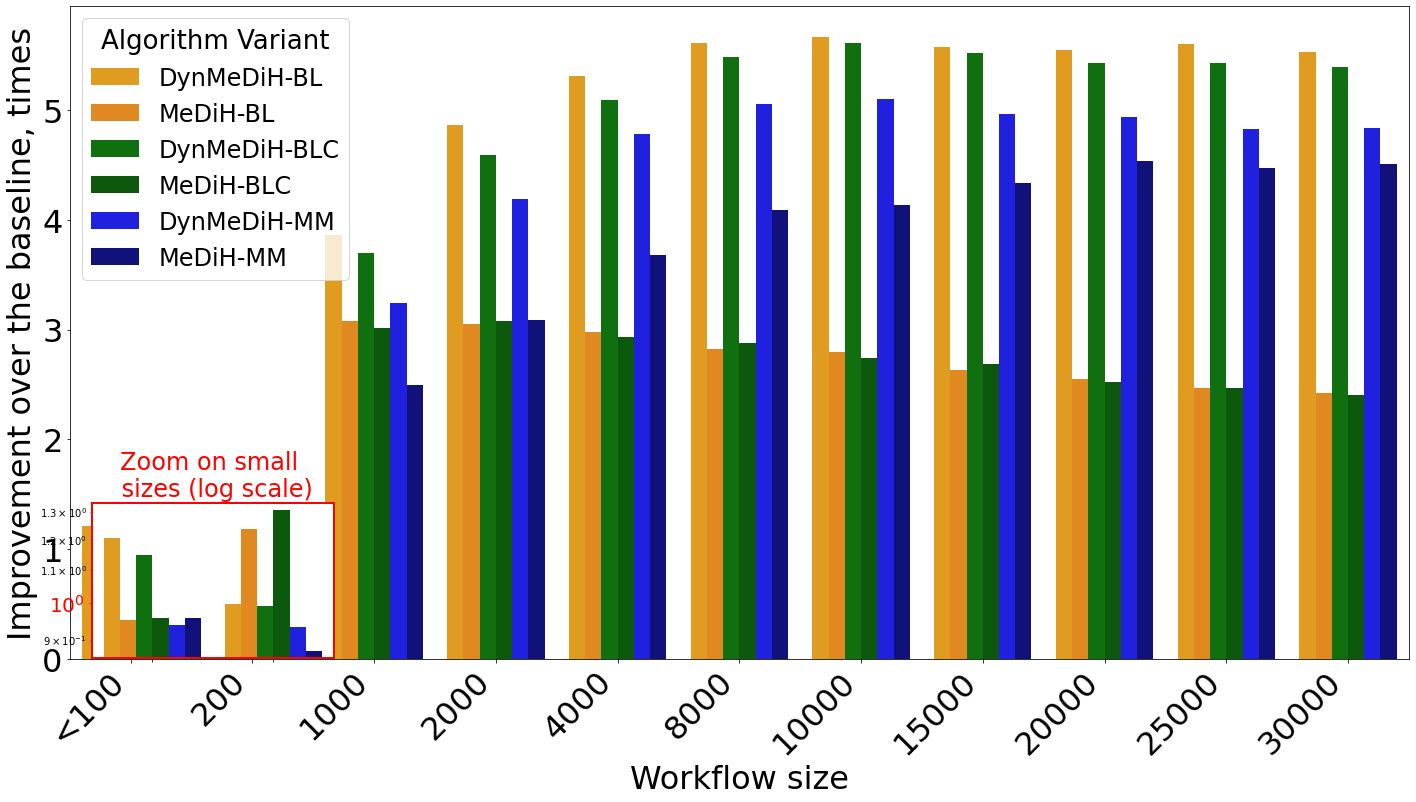

     size                   alg_rel     ratio
0     100    MeDiH-BL - dyn_vs_base  1.205388
1     100   MeDiH-BL - stat_vs_base  0.951083
2     100   MeDiH-BLC - dyn_vs_base  1.147698
3     100  MeDiH-BLC - stat_vs_base  0.958107
4     100    MeDiH-MM - dyn_vs_base  0.939013
..    ...                       ...       ...
61  30000   MeDiH-BL - stat_vs_base  2.421087
62  30000   MeDiH-BLC - dyn_vs_base  5.395856
63  30000  MeDiH-BLC - stat_vs_base  2.405687
64  30000    MeDiH-MM - dyn_vs_base  4.835432
65  30000   MeDiH-MM - stat_vs_base  4.510527

[66 rows x 3 columns]
alg_rel
MeDiH-BL - dyn_vs_base      3.949618
MeDiH-BL - stat_vs_base     2.318486
MeDiH-BLC - dyn_vs_base     3.837451
MeDiH-BLC - stat_vs_base    2.326588
MeDiH-MM - dyn_vs_base      3.455999
MeDiH-MM - stat_vs_base     2.969602
Name: ratio, dtype: float64


In [31]:
#############'THIS IS CORRECT ''''''''''''''''''''''''
#path = "./real-exps-correctparams/merged_final/*.txt"
path = "./results/merged/*.txt"
print(path)

#patterndevs = r'^modified_(BASE|A\d+)_(\d\ddev)'
patterndevs = r'^(BASE|A\d+)-(\d\ddev)'

dfs=read_dfs(path,patterndevs, 2)
#print(dfs)


#dfsVar1 = [dfsrw[('A1','10dev')], dfsrw[('A1','30dev')], dfsrw[('A1','50dev')]]
labels = ['A1', 'A2', 'A3', 'BASE']
dfsVar1 = [dfs[('A1','30dev')], dfs[('A2','30dev')], dfs[('A3','30dev')], dfs[('BASE','30dev')]]
#print(dfsVar1)
merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)
plot_df = buld_plot_df(merged_df_var1)
plotDynAndStaticVsBase(plot_df, "", "", ['stat_vs_base', 'dyn_vs_base'])#"for deviations of 30%", "Relative makespan improvement ",
allInternals = plot_df[plot_df['relation']=='internal']

In [86]:
# Define the size categories
def size_category(size):
    if size <= 200:
        return 'small'
    elif 1000 <= size <= 8000:
        return 'middle'
    elif 10000 <= size <= 18000:
        return 'large'
    elif 20000 <= size <= 30000:
        return 'largest'
    else:
        return 'other'

allInternals = allInternals.copy()
#print(allInternals.to_string())
# Add a new column for size group
allInternals['size_group'] = allInternals['size'].apply(size_category)

# Filter only valid categories
filtered = allInternals[allInternals['size_group'] != 'other']

# Group by algorithm and size_group, then compute geometric mean
result = filtered.groupby(['algorithm', 'size_group'])['ratio'].agg(gmean).reset_index()

# Optionally, sort the result
size_order = ['small', 'middle', 'large', 'largest']
result['size_group'] = pd.Categorical(result['size_group'], categories=size_order, ordered=True)
result = result.sort_values(['algorithm', 'size_group'])

print(result)

by_algo = allInternals.groupby('algorithm')['ratio'].agg(gmean).reset_index()
print(by_algo)

    algorithm size_group     ratio
3    MeDiH-BL      small  1.194239
2    MeDiH-BL     middle  0.908425
0    MeDiH-BL      large  0.849610
1    MeDiH-BL    largest  0.832975
7   MeDiH-BLC      small  1.216748
6   MeDiH-BLC     middle  0.895441
4   MeDiH-BLC      large  0.809096
5   MeDiH-BLC    largest  0.803900
11   MeDiH-MM      small  0.991663
10   MeDiH-MM     middle  0.769352
8    MeDiH-MM      large  0.902910
9    MeDiH-MM    largest  0.889525
   algorithm     ratio
0   MeDiH-BL  0.909648
1  MeDiH-BLC  0.888436
2   MeDiH-MM  0.862952


./results/merged/*.txt
No match found. A1-ndev.txt
No match found. A2-ndev.txt
No match found. A3-ndev.txt
No match found. BASE-ndev.txt
[                 wf_name     inp_size       ms_1_A1       ms_2_A1
0      atacseq_30000.dot  14091675276  1.380609e+09  1.791235e+09
1      chipseq_15000.dot  41366257414  3.266095e+09  1.023207e+10
2    methylseq_15000.dot   6761426956  1.227521e+08  7.637706e+08
3      atacseq_15000.dot   3908761308  2.104238e+08  1.840771e+08
4                  eager  19075314980  3.408557e+06  6.217068e+06
..                   ...          ...           ...           ...
252   methylseq_1000.dot   8885797810  1.131179e+07  2.044718e+07
253                eager  19132169434  3.137202e+06  5.723907e+06
254  methylseq_10000.dot  17027257018  3.095181e+08  2.140824e+09
255        eager_200.dot   8330435694  4.212150e+06  3.883172e+06
256    chipseq_10000.dot   4807293396  1.748258e+08  1.881276e+08

[257 rows x 4 columns],                  wf_name     inp_size       m

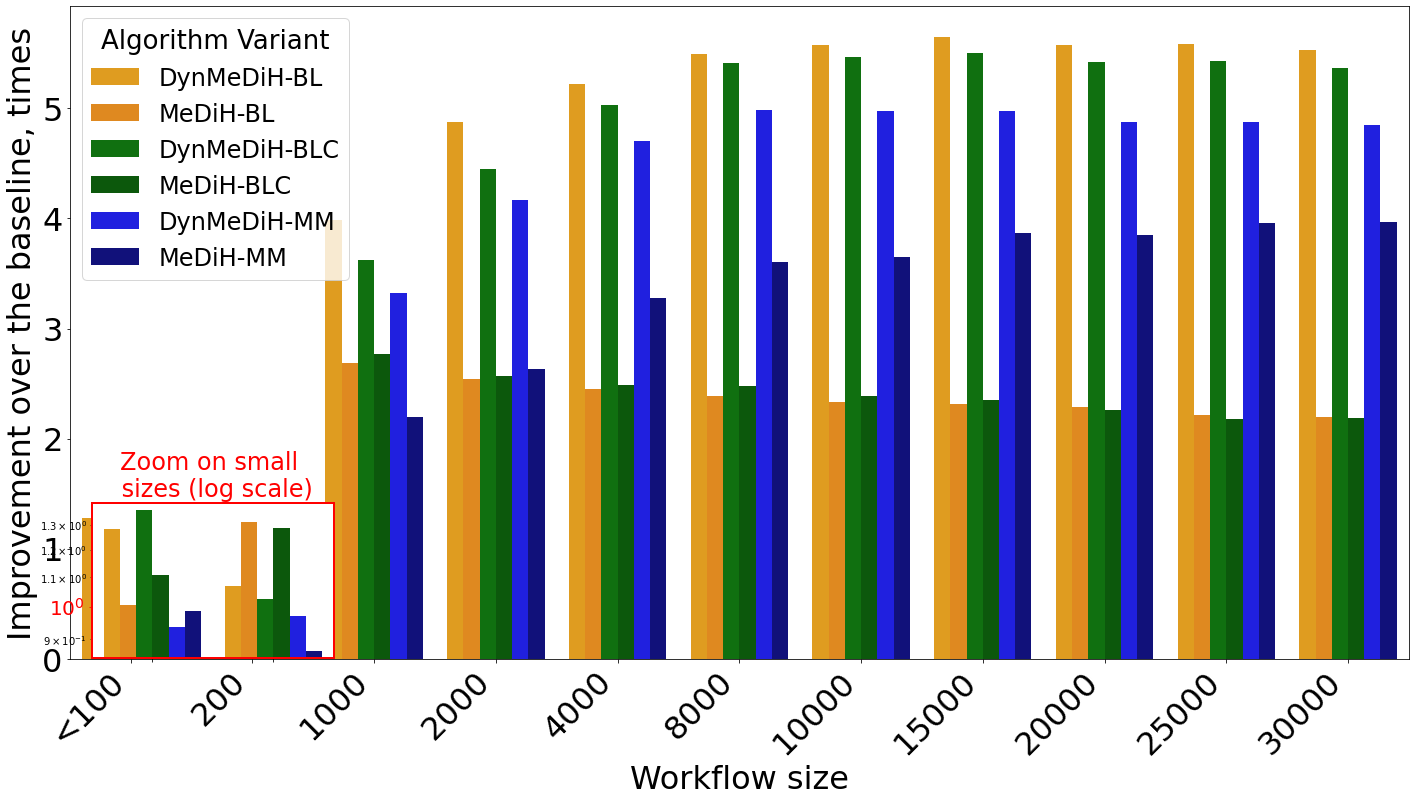

     size                   alg_rel     ratio
0     100    MeDiH-BL - dyn_vs_base  1.280982
1     100   MeDiH-BL - stat_vs_base  1.004737
2     100   MeDiH-BLC - dyn_vs_base  1.364490
3     100  MeDiH-BLC - stat_vs_base  1.106990
4     100    MeDiH-MM - dyn_vs_base  0.936069
..    ...                       ...       ...
61  30000   MeDiH-BL - stat_vs_base  2.193035
62  30000   MeDiH-BLC - dyn_vs_base  5.369634
63  30000  MeDiH-BLC - stat_vs_base  2.189775
64  30000    MeDiH-MM - dyn_vs_base  4.852883
65  30000   MeDiH-MM - stat_vs_base  3.967582

[66 rows x 3 columns]
alg_rel
MeDiH-BL - dyn_vs_base      3.994189
MeDiH-BL - stat_vs_base     2.079837
MeDiH-BLC - dyn_vs_base     3.869880
MeDiH-BLC - stat_vs_base    2.114629
MeDiH-MM - dyn_vs_base      3.456057
MeDiH-MM - stat_vs_base     2.673548
Name: ratio, dtype: float64


In [32]:
#### wf gtßen rausnehmen oder verschmelzen
 # 18k und evtl 25 k
#############'THIS IS CORRECT ''''''''''''''''''''''''
#path = "./real-exps-correctparams/merged_final/*.txt"
path = "./results/merged/*.txt"
print(path)

#patterndevs = r'^modified_(BASE|A\d+)_(\d\ddev)'
patterndevs = r'^(BASE|A\d+)-(\d\ddev)'

dfs=read_dfs(path,patterndevs, 2)
#print(dfs)


#dfsVar1 = [dfsrw[('A1','10dev')], dfsrw[('A1','30dev')], dfsrw[('A1','50dev')]]
labels = ['A1', 'A2', 'A3', 'BASE']
dfsVar1 = [dfs[('A1','50dev')], dfs[('A2','50dev')], dfs[('A3','50dev')], dfs[('BASE','50dev')]]
#print(dfsVar1)
merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)
plot_df = buld_plot_df(merged_df_var1)
plotDynAndStaticVsBase(plot_df, "deviations 50%", "Makespan improvement over baseline, ", ['stat_vs_base', 'dyn_vs_base'])#
#print(plot_df[plot_df['relation']=='internal'].to_string())
allInternals = plot_df[plot_df['relation']=='internal']

In [92]:
# Define the size categories
def size_category(size):
    if size <= 200:
        return 'small'
    elif 1000 <= size <= 8000:
        return 'middle'
    elif 10000 <= size <= 18000:
        return 'large'
    elif 20000 <= size <= 30000:
        return 'largest'
    else:
        return 'other'
def safe_gmean(x):
    x = np.array(x)
    x = x[x > 0]  # only positive values
    return gmean(x) if len(x) > 0 else np.nan    

allInternals = allInternals.copy()
print(allInternals)
# Add a new column for size group
allInternals['size_group'] = allInternals['size'].apply(size_category)

# Filter only valid categories
filtered = allInternals[allInternals['size_group'] != 'other']

# Group by algorithm and size_group, then compute geometric mean
result = filtered.groupby(['algorithm', 'size_group'])['ratio'].agg(safe_gmean).reset_index()

# Optionally, sort the result
size_order = ['small', 'middle', 'large', 'largest']
result['size_group'] = pd.Categorical(result['size_group'], categories=size_order, ordered=True)
result = result.sort_values(['algorithm', 'size_group'])

print(result)

by_algo = allInternals.groupby('algorithm')['ratio'].agg(safe_gmean).reset_index()
print(by_algo)

       size              wf_name     inp_size  relation     ratio algorithm
0     30000    atacseq_30000.dot  14091675276  internal  0.814058  MeDiH-BL
1     15000    chipseq_15000.dot  41366257414  internal  0.555916  MeDiH-BL
2     15000  methylseq_15000.dot   6761426956  internal  0.594389  MeDiH-BL
3     15000    atacseq_15000.dot   3908761308  internal  0.651701  MeDiH-BL
4       100                eager  19075314980  internal  2.388304  MeDiH-BL
...     ...                  ...          ...       ...       ...       ...
1892    100                eager  19132169434  internal  1.108192  MeDiH-MM
1893  10000  methylseq_10000.dot  17027257018  internal  1.176105  MeDiH-MM
1894    200        eager_200.dot   8330435694  internal  1.189068  MeDiH-MM
1895  18000  methylseq_18000.dot  22500260922  internal  1.050029  MeDiH-MM
1896  10000    chipseq_10000.dot   4807293396  internal  0.746527  MeDiH-MM

[813 rows x 6 columns]
    algorithm size_group     ratio
3    MeDiH-BL      small  1.1

./real-exps-correctparams/merged-test/*.csv
./real-exps-correctparams/merged-test/modified_A1_10dev.csv
./real-exps-correctparams/merged-test/modified_BASE_50dev.csv
./real-exps-correctparams/merged-test/modified_A1_50dev.csv
./real-exps-correctparams/merged-test/modified_A3_30dev.csv
./real-exps-correctparams/merged-test/modified_A1_30dev.csv
./real-exps-correctparams/merged-test/modified_A2_10dev.csv
./real-exps-correctparams/merged-test/modified_A3_10dev.csv
./real-exps-correctparams/merged-test/modified_A3_50dev.csv
./real-exps-correctparams/merged-test/modified_A2_50dev.csv
./real-exps-correctparams/merged-test/modified_BASE_10dev.csv
./real-exps-correctparams/merged-test/modified_A2_30dev.csv
./real-exps-correctparams/merged-test/modified_BASE_30dev.csv
!!!      Unnamed: 0  algo_nr              wf_name     inp_size  dur_alg1  \
0             0        1    atacseq_30000.dot  14091675276  1.270169   
1             1        1    chipseq_15000.dot  41366257414  0.626734   
2         

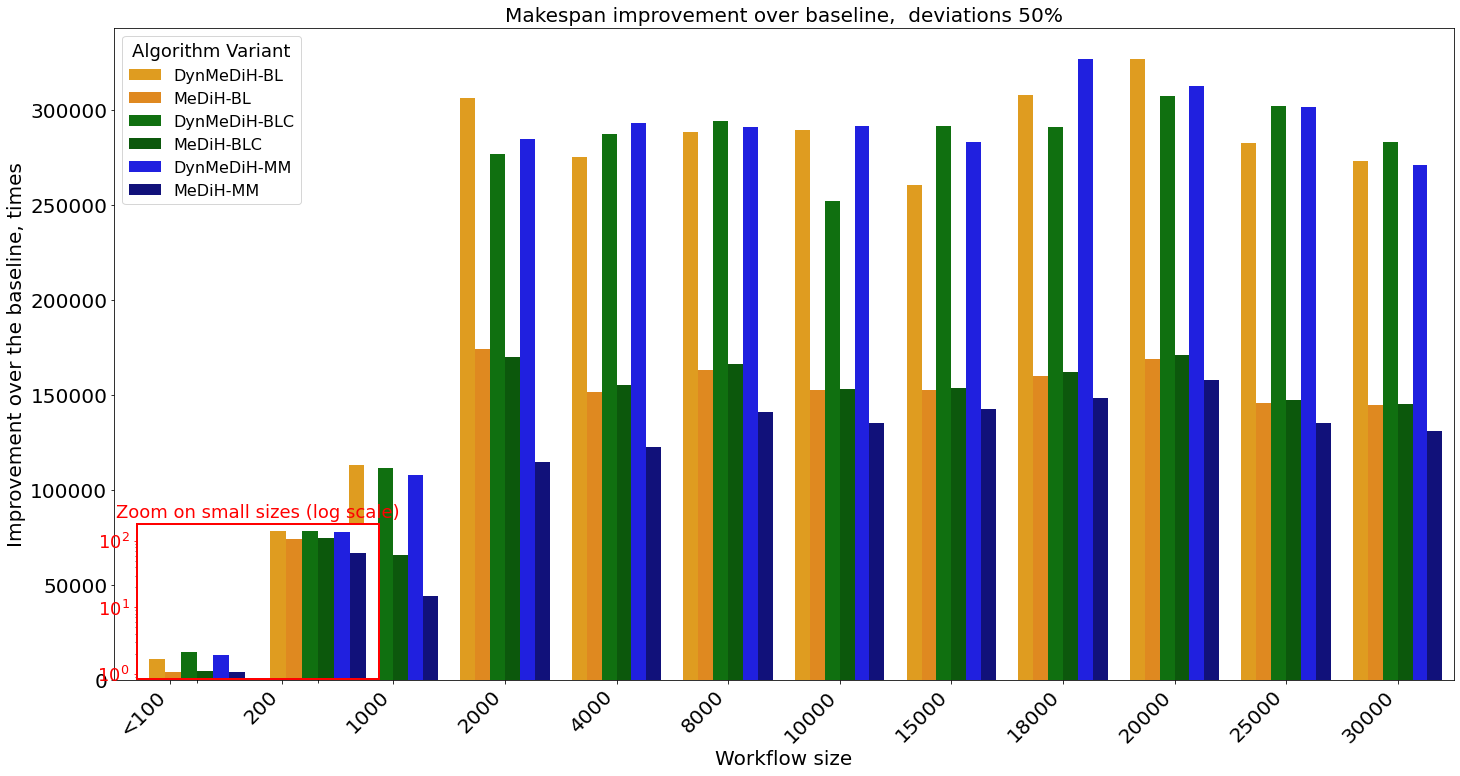

     size                   alg_rel          ratio
0     100    MeDiH-BL - dyn_vs_base       1.660424
1     100   MeDiH-BL - stat_vs_base       1.051601
2     100   MeDiH-BLC - dyn_vs_base       2.089416
3     100  MeDiH-BLC - stat_vs_base       1.088905
4     100    MeDiH-MM - dyn_vs_base       1.911727
..    ...                       ...            ...
67  30000   MeDiH-BL - stat_vs_base  144908.615615
68  30000   MeDiH-BLC - dyn_vs_base  283088.152120
69  30000  MeDiH-BLC - stat_vs_base  145205.884669
70  30000    MeDiH-MM - dyn_vs_base  271308.012512
71  30000   MeDiH-MM - stat_vs_base  131140.319193

[72 rows x 3 columns]
alg_rel
MeDiH-BL - dyn_vs_base      51831.111953
MeDiH-BL - stat_vs_base     29418.193534
MeDiH-BLC - dyn_vs_base     52455.935987
MeDiH-BLC - stat_vs_base    29735.470087
MeDiH-MM - dyn_vs_base      52824.158761
MeDiH-MM - stat_vs_base     24586.257710
Name: ratio, dtype: float64


In [25]:

path = "./real-exps-correctparams/merged-test/*.csv"
print(path)

#patterndevs = r'^modified_(BASE|A\d+)_(\d\ddev)'
patterndevs = r'^modified_(BASE|A\d+)_(\d\ddev)'


dfs = {}

for fname in glob.glob(path):
    print(fname)
    df = pd.read_csv(fname, delimiter=',', header=0, on_bad_lines="skip")
    basename = os.path.basename(fname)
    match = re.search(patterndevs, basename)

    if match:
        algorithm = match.group(1)
        variant = match.group(2)
        dfs[(algorithm, variant)] = df
    else:
        print("No match found. " + basename)
    

#print(dfs)


#dfsVar1 = [dfsrw[('A1','10dev')], dfsrw[('A1','30dev')], dfsrw[('A1','50dev')]]
labels = ['A1', 'A2', 'A3', 'BASE']
dfsVar1 = [dfs[('A1','50dev')], dfs[('A2','50dev')], dfs[('A3','50dev')], dfs[('BASE','50dev')]]
#print(dfsVar1)


def merge_correct_columns1(dfsOurVar, lbs):
    renamed_dfs = []
    for df, label in zip(dfsOurVar, lbs):
        # Rename selected columns
        print("!!!", df)
        renamed = df[['wf_name', 'inp_size', 'ms_1', 'ms_2']].copy()
        renamed = renamed.rename(columns={
            'ms_1': f'ms_1_{label}',
            'ms_2': f'ms_2_{label}',
        })    
        renamed_dfs.append(renamed)


    # Merge them all on 'wf_name'
   
    merged_df = reduce(lambda left, right: pd.merge(left, right, on=['wf_name', 'inp_size']), renamed_dfs)


    merged_df['size'] = merged_df['wf_name'].str.extract(r'_(\d+)\.')[0].fillna("100")
    merged_df['size'] = merged_df['size'].astype(int)


    for col in merged_df.columns:
        if col.startswith("ms_"):
            merged_df[col] = pd.to_numeric(merged_df[col], errors="coerce")
    
    return merged_df


merged_df_var1 = merge_correct_columns1(dfsVar1, labels)
#print(merged_df_var1)
plot_df = buld_plot_df(merged_df_var1)
plotDynAndStaticVsBase(plot_df, "deviations 50%", "Makespan improvement over baseline, ", ['stat_vs_base', 'dyn_vs_base'])#
#print(plot_df[plot_df['relation']=='internal'].to_string())
allInternals = plot_df[plot_df['relation']=='internal']

In [28]:
path = "./real-exps-correctparams/merged_final/*.txt"
print(path)

#patterndevs = r'^modified_(BASE|A\d+)_(\d\ddev)'
patterndevs = r'^(BASE|A\d+)-(\d\ddev)'

dfs2=read_dfs(path,patterndevs, 2)
#print(dfs)


#dfsVar1 = [dfsrw[('A1','10dev')], dfsrw[('A1','30dev')], dfsrw[('A1','50dev')]]
labels = ['A1', 'A2', 'A3', 'BASE']
dfsVar2 = [dfs2[('A1','50dev')], dfs2[('A2','50dev')], dfs2[('A3','50dev')], dfs2[('BASE','50dev')]]
#print(dfsVar1)
merged_df_var2 = merge_correct_columns(dfsVar2, labels)
#print(merged_df_var1)
plot_df2 = buld_plot_df(merged_df_var2)

#print(plot_df.to_string())
#print("!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")
#print(plot_df2.to_string())

merged = plot_df.merge(
    plot_df2,
    on=['wf_name', 'inp_size', 'relation', 'algorithm'],
    suffixes=('_1', '_2')
)
merged_int = merged[merged["relation"]=="internal"]
print(merged_int.to_string())

./real-exps-correctparams/merged_final/*.txt
./real-exps-correctparams/merged_final/BASE-50dev.txt
./real-exps-correctparams/merged_final/A1-50dev.txt
./real-exps-correctparams/merged_final/A2-50dev.txt
./real-exps-correctparams/merged_final/BASE-30dev.txt
./real-exps-correctparams/merged_final/A2-10dev.txt
./real-exps-correctparams/merged_final/A1-30dev.txt
./real-exps-correctparams/merged_final/A3-30dev.txt
./real-exps-correctparams/merged_final/BASE-10dev.txt
./real-exps-correctparams/merged_final/A2-30dev.txt
./real-exps-correctparams/merged_final/A3-50dev.txt
./real-exps-correctparams/merged_final/A3-10dev.txt
./real-exps-correctparams/merged_final/A1-10dev.txt
!!!      algo_nr              wf_name     inp_size  dur_alg1          ms_1  \
0          1    atacseq_30000.dot  14091675276  1.270169  1.603448e+09   
1          1    chipseq_15000.dot  41366257414  0.626734  2.711482e+09   
2          1  methylseq_15000.dot   6761426956  0.619555  9.600079e+07   
3          1    atacseq_1

In [1]:


def plotDynAndStaticVsBaseNoInset(our_df, deviationsText, titleText, relations):
   
    filtered_df = our_df[our_df['relation'].isin(relations)].copy()# ['internal']
    filtered_df['alg_rel'] = filtered_df['algorithm'] + ' - ' + filtered_df['relation']
    #print("filtered_df\n", filtered_df)

    fig, ax = plt.subplots(figsize=(24, 12))
    ax = sns.barplot(
        data=filtered_df,
        x='size',
        y='ratio',
        hue='alg_rel',
        estimator=gmean,
        palette=palette,
        ci=None
    )
    if "internal" in relations:
        baseline_line = plt.axhline(y=1, color='red', linestyle='--', linewidth=1.5, label='Equal')    
    plt.xticks(rotation=45)
  
    plt.yticks(fontsize=32)
    plt.xticks(fontsize=32)
    plt.xlabel('Workflow size', fontsize=32)
    plt.ylabel('Improvement over the baseline, times', fontsize=32)
    plt.legend(fontsize=32, title_fontsize=32)  


    
    xticks = ax.get_xticks()
    xticklabels = [tick.get_text() for tick in ax.get_xticklabels()]

    # Replace label "100" with "<100"
    new_labels = ["<100" if lbl == "100" else lbl for lbl in xticklabels]

    # Apply the modified labels
    ax.set_xticklabels(new_labels, fontsize=32, rotation=45, ha='right')
    ax.set_yscale("log")

    handles, labels = ax.get_legend_handles_labels()

    # Apply the mapping
    pretty_labels = [label_map.get(lbl, lbl) for lbl in labels]

    
    # Set updated legend
    ax.legend(handles, pretty_labels, title="Algorithm Variant", fontsize=24, title_fontsize=26)
   # plt.title(f'{titleText} {deviationsText}', fontsize=28) #Makespan improvement over the baseline,

  
    plt.savefig(f'improv_ov_baseline_newest_{deviationsText}.png', facecolor='white',  bbox_inches='tight')
    plt.show()

    grouped = filtered_df.groupby(['size', 'alg_rel'])['ratio'].agg(safe_gmean).reset_index()
    # Print the values used for bar heights
    #print(grouped)

    gr = grouped.groupby(['alg_rel'])['ratio'].agg(safe_gmean)
   # print(gr)